In [49]:
from matplotlib import pyplot as plt
import pandas as pd

import os
import glob

In [55]:
os.getcwd()

'/home/niloofarhp/Documents/Projects/flowdataset/evaluate'

In [56]:
path = '../images/'
extension = 'csv'
csv_filenames = glob.glob('{}/*.{}'.format(path, extension))
print(csv_filenames)


['../images/rotation_rotate_bar_gma.csv', '../images/rotation_rotate_gma.csv', '../images/linear_movement_static_gma.csv', '../images/linear_movement_rotate_bar_gma.csv', '../images/linear_movement_slide_bar_gma.csv', '../images/fixed_random_rotate_bar_gma.csv', '../images/rotation_static_gma.csv', '../images/linear_movement_static_bar_gma.csv', '../images/fixed_random_static_bar_gma.csv', '../images/linear_movement_slide_gma.csv', '../images/linear_movement_rotate_gma.csv', '../images/rotation_slide_bar_gma.csv', '../images/rotation_static_bar_gma.csv', '../images/fixed_random_slide_gma.csv', '../images/rotation_slide_gma.csv']


In [57]:
list_dataframes = []
for fname in csv_filenames:
    df = pd.read_csv(fname)
    df['file_name'] = os.path.basename(fname)
    list_dataframes.append(df)

In [58]:

print(len(list_dataframes))
print(list_dataframes)

15
[                 video_type  video_name         epe  epe_rel  epe_fg  \
0   rotation_rotate_bar_003           3    5.374115      0.0     0.0   
1   rotation_rotate_bar_007           4    7.204116      0.0     0.0   
2   rotation_rotate_bar_007           8    4.850725      0.0     0.0   
3   rotation_rotate_bar_001           5   29.658993      0.0     0.0   
4   rotation_rotate_bar_003           2    5.974660      0.0     0.0   
5   rotation_rotate_bar_007           5    9.995388      0.0     0.0   
6   rotation_rotate_bar_003           4    5.295627      0.0     0.0   
7   rotation_rotate_bar_007           1   11.487445      0.0     0.0   
8   rotation_rotate_bar_007           7    5.566883      0.0     0.0   
9   rotation_rotate_bar_007           0   15.550651      0.0     0.0   
10  rotation_rotate_bar_003           1   16.512238      0.0     0.0   
11  rotation_rotate_bar_001           1   14.610280      0.0     0.0   
12  rotation_rotate_bar_007           3    5.101348      0.0

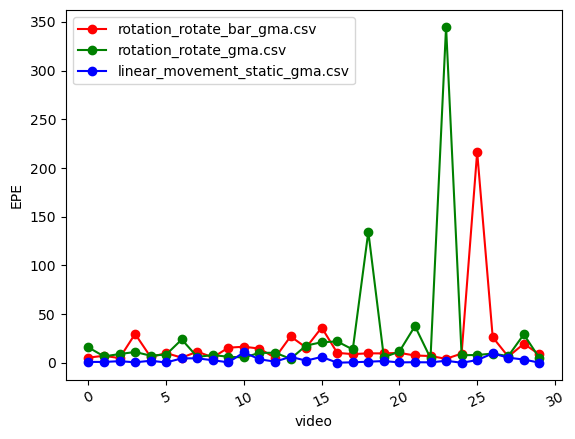

In [59]:
_,fname = os.path.split(csv_filenames[0])
plt.plot(list_dataframes[0].epe, color = 'r', linestyle = 'solid', marker = 'o',label = '{}'.format(fname))
_,fname = os.path.split(csv_filenames[1])
plt.plot(list_dataframes[1].epe, color = 'g', linestyle = 'solid', marker = 'o',label = '{}'.format(fname))
_,fname = os.path.split(csv_filenames[2])
plt.plot(list_dataframes[2].epe, color = 'b', linestyle = 'solid', marker = 'o',label = '{}'.format(fname))
#_,fname = os.path.split(csv_filenames[4])
#plt.plot(list_dataframes[4].epe, color = 'y', linestyle = 'solid', marker = 'o',label = '{}'.format(fname))
  
plt.xticks(rotation = 25)
plt.xlabel('video')
plt.ylabel('EPE')
plt.legend()
plt.show()

In [60]:
def find_files( fnames, 
                include_list,
                exclude_list ) :
    select_fnames = [ fname for fname in fnames if all(d in fname for d in include_list) 
                     and not any(e in fname for e in exclude_list ) ]
    return select_fnames

In [61]:
find_files(csv_filenames, ['arflow'], ['bar'])

[]

In [62]:
mega_df = pd.concat(list_dataframes, ignore_index = True)


In [63]:
mega_df.loc[30,:]

video_type        rotation_rotate_007
video_name                          5
epe                         15.762512
epe_rel                           0.0
epe_fg                            0.0
epe_fg_rel                        0.0
epe_bg                            0.0
epe_bg_rel                        0.0
matched                           0.0
unmatched                         0.0
d0_5                              0.0
d5_30                             0.0
d30_70                            0.0
s0_5                              0.0
s5_15                             0.0
s15_                              0.0
file_name     rotation_rotate_gma.csv
Name: 30, dtype: object

In [64]:
# Split video_type column into ego_motion, object_motion, bar, object_cnt
vt = mega_df.video_type.str.replace("fixed_random", "fixed-random").str.replace("linear_movement","linear-movement").str.split("_")
ego_motion = vt.str[0]
ego_motion = ego_motion.str.replace("fixed-random", "fixed_random")
ego_motion = ego_motion.str.replace("linear-movement","linear_movement")
object_motion = vt.str[1]
object_cnt = vt.str[-1].astype(int) 
bar = mega_df.video_type.str.contains("bar")
# Get the method from file_name
fn = mega_df.file_name.str.replace(".csv","")
method = fn.str.split("_").str[-1]
# Fix the panda frame
del mega_df["video_type"]
del mega_df["file_name"]
mega_df["ego_motion"] = ego_motion
mega_df["object_motion"] = object_motion
mega_df["object_cnt"] = object_cnt
mega_df["bar"] = bar
mega_df["method"] = method

/tmp/ipykernel_10004/2330503268.py:10: FutureWarning: The default value of regex will change from True to False in a future version.
  fn = mega_df.file_name.str.replace(".csv","")


In [65]:
mega_df.describe()



,video_name,epe,epe_rel,epe_fg,epe_fg_rel,epe_bg,epe_bg_rel,matched,unmatched,d0_5,d5_30,d30_70,s0_5,s5_15,s15_,object_cnt
count,406.000000,406.000000,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.0,406.000000
mean,4.224138,8.110741,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.660099
std,2.859078,23.036251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.497947
min,0.000000,0.027549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
25%,2.000000,1.300383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
50%,4.000000,3.899371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000
75%,7.000000,7.922716,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000
max,9.000000,344.922618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000


In [45]:
raft_df = mega_df.loc[mega_df['method']=='raft']

In [89]:
raft_df.describe()

,video_name,epe,epe_rel,epe_fg,epe_fg_rel,epe_bg,epe_bg_rel,matched,unmatched,d0_5,d5_30,d30_70,s0_5,s5_15,s15_,object_cnt
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
gma_df = mega_df.loc[mega_df['method']=='gma']

In [19]:
gma_df.describe()

,video_name,epe,epe_rel,epe_fg,epe_fg_rel,epe_bg,epe_bg_rel,matched,unmatched,d0_5,d5_30,d30_70,s0_5,s5_15,s15_,object_cnt
count,361.000000,361.000000,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.0,361.000000
mean,4.293629,9.195980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.659280
std,2.864958,24.790481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.498384
min,0.000000,0.024753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
25%,2.000000,1.344778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
50%,4.000000,4.541482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000
75%,7.000000,9.067089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000
max,9.000000,343.965539,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000


In [90]:
gmflow_df = mega_df.loc[mega_df['method']=='gmflow']

In [91]:
gmflow_df.describe()

,video_name,epe,epe_rel,epe_fg,epe_fg_rel,epe_bg,epe_bg_rel,matched,unmatched,d0_5,d5_30,d30_70,s0_5,s5_15,s15_,object_cnt
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
arflow_df = mega_df.loc[mega_df['method']=='arflow']

In [58]:
arflow_df.describe()

,video_name,epe,epe_rel,epe_fg,epe_fg_rel,epe_bg,epe_bg_rel,matched,unmatched,d0_5,d5_30,d30_70,s0_5,s5_15,s15_,object_cnt
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
pd.pivot_table(mega_df, values='unmatched',
                index=["ego_motion","method"],columns="bar")

,bar,False,True
ego_motion,method,,
fixed_random,gma,0.0,0.0
linear_movement,gma,0.0,0.0
rotation,gma,0.0,0.0


In [67]:
print(pd.get_option("display.max_rows"))
pd.set_option("display.max_rows", None)


None


In [68]:
#after about 8 epochs
pd.pivot_table(mega_df, values='epe', index=["ego_motion","method"],columns="bar")

,bar,False,True
ego_motion,method,,
fixed_random,gma,2.048111,1.002520
linear_movement,gma,2.899226,2.739116
rotation,gma,21.075888,14.630120


In [33]:
#pretrained
pd.pivot_table(mega_df, values='epe', index=["ego_motion","method"],columns="bar")


,bar,False,True
ego_motion,method,,
fixed_random,gma,0.316243,0.293105
linear_movement,gma,0.271453,0.313949
rotation,gma,7.385196,3.833033


In [67]:
#after >200000 iteration
pd.pivot_table(mega_df, values='epe', index=["ego_motion","method"],columns="bar")

,bar,False,True
ego_motion,method,,
fixed_random,gma,2.088962,1.008657
linear_movement,gma,3.139140,2.995896
rotation,gma,22.492732,15.043687


In [22]:
pd.reset_option("display.max_rows")

In [23]:
pd.pivot_table(mega_df, values='d0_5', index=["ego_motion","object_motion","object_cnt","bar"],columns="method")


method                                               gma
ego_motion      object_motion object_cnt bar            
fixed_random    rotate        1          True   2.232231
                              3          True   2.886023
                              7          True   2.473035
                slide         1          False  1.375837
                              3          False  1.603955
                              7          False  2.201631
                static        1          True   0.029647
                              3          True   0.407472
                              7          True   1.511799
linear_movement rotate        1          False  1.882377
                                         True   1.332524
                              3          False  1.787029
                                         True   1.714463
                              7          False  1.900652
                                         True   1.851713
                slide         1          False  1.123483
                                         True   1.101369
                              3          False  1.689160
                                         True   1.401361
                              7          False  1.580983
                                         True   1.746600
                static        1          False  0.319411
                                         True   0.573485
                              3          False  0.776257
                                         True   0.757543
                              7          False  0.547062
                                         True   0.989820
rotation        rotate        1          False  2.355767
                                         True   1.987318
                              3          False  2.444136
                                         True   2.270609
                              7          False  2.561113
                                         True   2.743119
                slide         1          False  2.638389
                              3          False  2.819747
                              7          False  2.645308
                static        1          False  1.487006
                                         True   0.786568
                              3          False  0.856821
                                         True   1.332256
                              7          False  0.988802
                                         True   1.725189